In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.spectral_norm as spectral_norm

import segmentation_models_pytorch as smp   # DeepLabV3+

import cv2
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

c:\Users\Linh\anaconda3\envs\seggan\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

TRAIN_ROOT  = "./LoveDA_patch/Train"
VAL_ROOT    = "./LoveDA_patch/Val"
TEST_ROOT   = "./Test/Test"

IMG_SIZE    = 512          # DeepLabV3+ hoạt động tốt hơn ở 512 (ResNet50 stride 16)
BATCH_SIZE  = 4            # Giảm xuống do model lớn hơn
EPOCHS      = 100
NUM_CLASSES = 7            # Background, Building, Road, Water, Barren, Forest, Agricultural

LR_G        = 1e-4
LR_D        = LR_G / 4
LAMBDA_ADV  = 0.01         # Trọng số adversarial loss

# LoveDA official color map
COLOR_MAP = np.array([
    [255, 255, 255],   # 0: Background
    [255,   0,   0],   # 1: Building
    [255, 255,   0],   # 2: Road
    [  0,   0, 255],   # 3: Water
    [159, 129, 183],   # 4: Barren
    [  0, 255,   0],   # 5: Forest
    [255, 195, 128],   # 6: Agricultural
], dtype=np.uint8)

CLASS_NAMES = ["Background", "Building", "Road", "Water", "Barren", "Forest", "Agricultural"]


Device: cuda


In [3]:
train_transform = A.Compose([
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.OneOf([
        A.HorizontalFlip(p=1.0),
        A.VerticalFlip(p=1.0),
        A.RandomRotate90(p=1.0),
        A.Transpose(p=1.0),
    ], p=0.75),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, p=1.0),
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    ], p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


class PatchDataset(Dataset):
    def __init__(self, root, transform=None):
        self.img_dir   = os.path.join(root, "images")
        self.mask_dir  = os.path.join(root, "masks")
        self.images    = sorted(os.listdir(self.img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        name = self.images[idx]
        img  = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, name), cv2.IMREAD_GRAYSCALE).astype(np.int32)

        # Mapping nhãn LoveDA: 1-7 → 0-6, ignore (0 và 255) → 0
        mask[mask == 255] = 1
        mask = np.clip(mask - 1, 0, NUM_CLASSES - 1).astype(np.uint8)

        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out["image"]
            mask = out["mask"].long()
        else:
            img  = torch.tensor(img / 255.0).permute(2,0,1).float()
            mask = torch.tensor(mask).long()
        return img, mask


class LoveDATestDataset(Dataset):
    def __init__(self, root):
        self.images = []
        for area in ["Rural", "Urban"]:
            d = os.path.join(root, area, "images_png")
            for f in sorted(os.listdir(d)):
                self.images.append(os.path.join(d, f))

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]
        img  = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        return img, path



In [4]:
train_ds = PatchDataset(TRAIN_ROOT, transform=train_transform)
val_ds   = PatchDataset(VAL_ROOT,   transform=val_transform)
test_ds  = LoveDATestDataset(TEST_ROOT)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}")


Train: 10,088 | Val: 6,676 | Test: 1,796


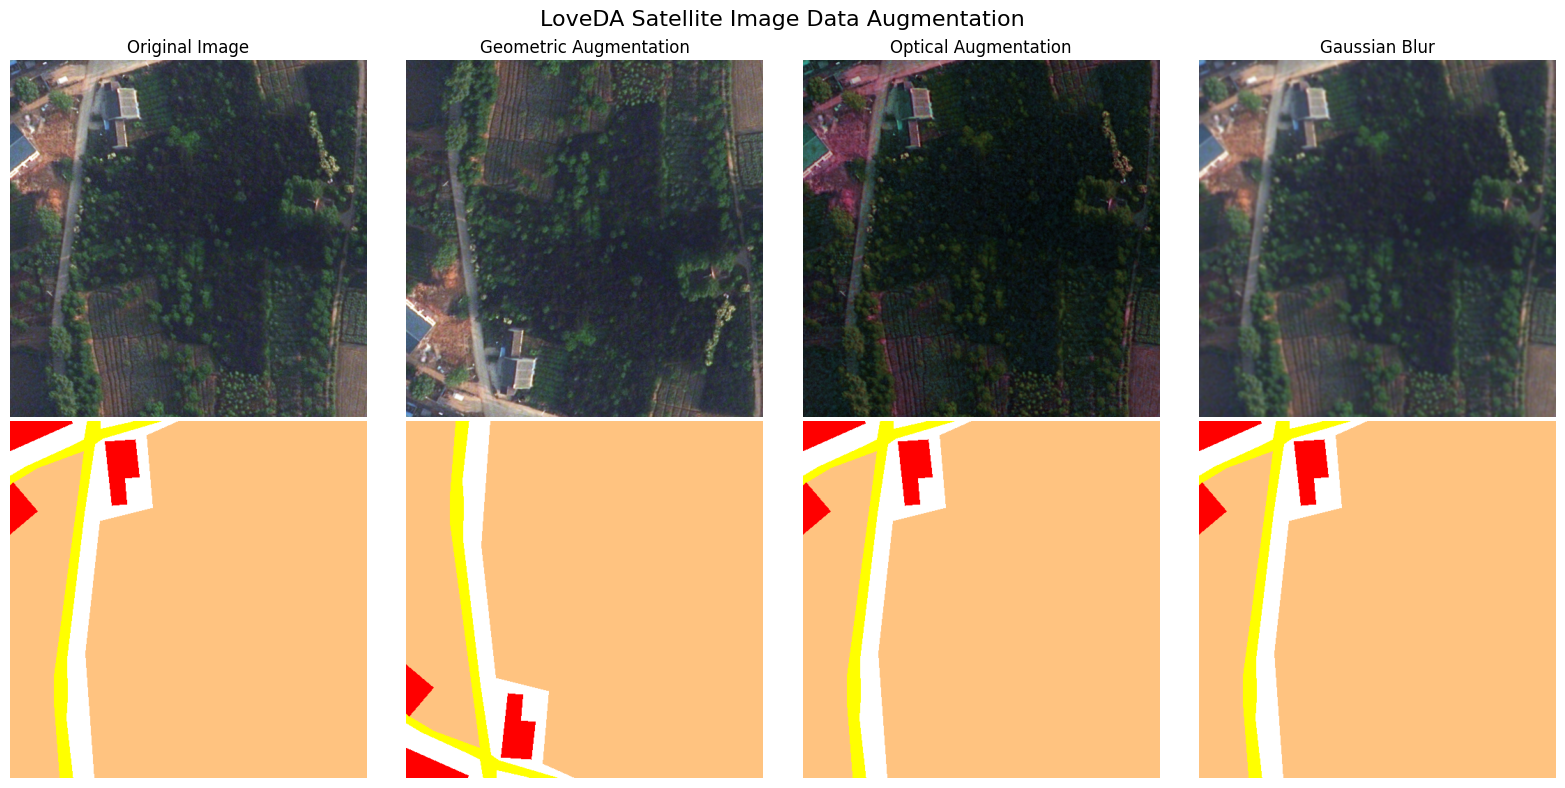

In [5]:
# ===== FINAL VERSION KHÔNG BAO GIỜ ĐEN =====

import matplotlib.pyplot as plt
import albumentations as A
import numpy as np
import torch

vis_ds = PatchDataset(TRAIN_ROOT, transform=None)
img, mask = vis_ds[0]

# ===== convert chuẩn =====
if isinstance(img, torch.Tensor):
    img = img.permute(1, 2, 0).cpu().numpy()

if isinstance(mask, torch.Tensor):
    mask = mask.cpu().numpy()

# FIX scale
if img.max() <= 1.0:
    img = (img * 255).astype(np.uint8)
else:
    img = img.astype(np.uint8)

mask = mask.astype(np.uint8)

# ===== augment =====
geom_transform = A.Compose([
    A.RandomRotate90(p=1.0),
    A.HorizontalFlip(p=1.0),
])

optical_transform = A.Compose([
    A.RandomBrightnessContrast(p=1.0),
    A.HueSaturationValue(p=1.0),
])

blur_transform = A.Compose([
    A.GaussianBlur(blur_limit=(5,7), p=1.0),
])

aug_geom = geom_transform(image=img, mask=mask)
aug_opt  = optical_transform(image=img, mask=mask)
aug_blur = blur_transform(image=img, mask=mask)

# ===== mask to color =====
def mask_to_color(mask):
    return COLOR_MAP[mask]

# ===== plot =====
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

titles = ["Original Image", "Geometric Augmentation", "Optical Augmentation", "Gaussian Blur"]

axes[0,0].imshow(img)
axes[0,1].imshow(aug_geom["image"])
axes[0,2].imshow(aug_opt["image"])
axes[0,3].imshow(aug_blur["image"])

axes[1,0].imshow(mask_to_color(mask))
axes[1,1].imshow(mask_to_color(aug_geom["mask"]))
axes[1,2].imshow(mask_to_color(aug_opt["mask"]))
axes[1,3].imshow(mask_to_color(aug_blur["mask"]))

for i in range(4):
    axes[0,i].set_title(titles[i])
    axes[0,i].axis("off")
    axes[1,i].axis("off")

plt.suptitle("LoveDA Satellite Image Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
def compute_class_weights(dataset, num_classes):
    print("Đang tính class weights từ tập Train...")
    freq = np.zeros(num_classes, dtype=np.float64)
    for _, mask in tqdm(dataset, desc="Counting pixels"):
        m = mask.numpy() if hasattr(mask, "numpy") else np.array(mask)
        for c in range(num_classes):
            freq[c] += (m == c).sum()
    freq_norm = freq / freq.sum()
    med = np.median(freq_norm[freq_norm > 0])
    w   = np.where(freq_norm > 0, med / freq_norm, 0.0)
    w   = w / w.max()  # scale về [0, 1] rồi nhân num_classes
    w   = w / w.sum() * num_classes
    print(f"Class weights: {np.round(w, 3)}")
    print(f"  {'  '.join(f'{n}={v:.2f}' for n,v in zip(CLASS_NAMES, w))}")
    return torch.tensor(w, dtype=torch.float32).to(device)

class_weights = compute_class_weights(train_ds, NUM_CLASSES)

Đang tính class weights từ tập Train...


Counting pixels: 100%|██████████| 10088/10088 [01:47<00:00, 94.00it/s]


Class weights: [0.23  0.827 1.736 1.431 1.754 0.569 0.453]
  Background=0.23  Building=0.83  Road=1.74  Water=1.43  Barren=1.75  Forest=0.57  Agricultural=0.45


In [6]:
G = smp.DeepLabV3Plus(
    encoder_name        = "resnet50",
    encoder_weights     = "imagenet",   # Pretrained ImageNet — tăng mạnh hiệu năng
    in_channels         = 3,
    classes             = NUM_CLASSES,
    activation          = None,         # Raw logits — để tương thích với CE loss
).to(device)

num_params_G = sum(p.numel() for p in G.parameters()) / 1e6
print(f"Generator (DeepLabV3+ ResNet50): {num_params_G:.1f}M params")

Generator (DeepLabV3+ ResNet50): 26.7M params


In [7]:
class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=3 + NUM_CLASSES):
        super().__init__()
        def block(ic, oc, stride=2):
            return nn.Sequential(
                spectral_norm(nn.Conv2d(ic, oc, 4, stride=stride, padding=1)),
                nn.BatchNorm2d(oc) if oc != 64 else nn.Identity(),
                nn.LeakyReLU(0.2, inplace=True),
            )
        self.model = nn.Sequential(
            block(in_ch, 64,  stride=2),   # No BN on first layer
            block(64,    128, stride=2),
            block(128,   256, stride=2),
            block(256,   512, stride=1),   # stride=1 ở đây để giữ receptive field
            spectral_norm(nn.Conv2d(512, 1, 4, stride=1, padding=1)),
        )

    def forward(self, x):
        return self.model(x)

D = PatchDiscriminator(in_ch=3 + NUM_CLASSES).to(device)
num_params_D = sum(p.numel() for p in D.parameters()) / 1e6
print(f"Discriminator (PatchGAN 70x70): {num_params_D:.1f}M params")


Discriminator (PatchGAN 70x70): 2.8M params


In [8]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs  = torch.softmax(logits, dim=1)
        onehot = F.one_hot(targets, logits.shape[1]).permute(0,3,1,2).float()
        inter  = (probs * onehot).sum(dim=(2,3))
        union  = probs.sum(dim=(2,3)) + onehot.sum(dim=(2,3))
        dice   = (2 * inter + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

gan_loss  = nn.BCEWithLogitsLoss()
ce_loss   = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-1)
dice_loss = DiceLoss()


In [9]:
opt_G = torch.optim.AdamW([
    {"params": G.encoder.parameters(), "lr": LR_G * 0.1},   # Fine-tune encoder nhẹ
    {"params": G.decoder.parameters(), "lr": LR_G},
    {"params": G.segmentation_head.parameters(), "lr": LR_G},
], betas=(0.9, 0.999), weight_decay=1e-4)

opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

# CosineAnnealingLR — giảm LR mượt từ đỉnh xuống eta_min
sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=EPOCHS, eta_min=1e-6)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=EPOCHS, eta_min=1e-7)


In [10]:
def compute_miou(logits, targets, num_classes):
    """Tính mIoU per-class rồi lấy trung bình (bỏ qua class không xuất hiện)."""
    preds = logits.argmax(dim=1).cpu().numpy()
    tgts  = targets.cpu().numpy()
    ious  = []
    for c in range(num_classes):
        pred_c   = preds == c
        target_c = tgts  == c
        inter    = (pred_c & target_c).sum()
        union    = (pred_c | target_c).sum()
        if union > 0:
            ious.append(inter / union)
    return np.mean(ious) if ious else 0.0


def validate():
    G.eval()
    total_loss, total_miou = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = torch.clamp(masks.to(device), 0, NUM_CLASSES - 1)
            logits = G(imgs)
            loss   = ce_loss(logits, masks) + dice_loss(logits, masks)
            miou   = compute_miou(logits, masks, NUM_CLASSES)
            total_loss += loss.item()
            total_miou += miou
    n = len(val_loader)
    return total_loss / n, total_miou / n


In [11]:
# class EarlyStopping:
#     def __init__(self, patience=15, path="best_generator.pth"):
#         self.patience   = patience
#         self.counter    = 0
#         self.best_miou  = None
#         self.early_stop = False
#         self.path       = path

#     def __call__(self, miou, model):
#         if self.best_miou is None or miou > self.best_miou:
#             self.best_miou = miou
#             torch.save(model.state_dict(), self.path)
#             self.counter = 0
#             print(f"  ✓ New best mIoU: {miou:.4f}  →  Saved to {self.path}")
#         else:
#             self.counter += 1
#             print(f"  EarlyStopping [{self.counter}/{self.patience}]  (best: {self.best_miou:.4f})")
#             if self.counter >= self.patience:
#                 self.early_stop = True

# early_stopping = EarlyStopping(patience=15, path="best_generator.pth")


In [12]:
print("\n" + "="*65)
print("  GAN Satellite Segmentation  |  DeepLabV3+ ResNet50 + PatchGAN")
print("="*65)

history = {"g_loss": [], "d_loss": [], "val_loss": [], "val_miou": []}

best_miou = 0.0

for epoch in range(EPOCHS):

    G.train()
    D.train()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1:3d}/{EPOCHS}")
    ep_g, ep_d = 0.0, 0.0

    for imgs, masks in loop:

        imgs  = imgs.to(device)
        masks = torch.clamp(masks.to(device), 0, NUM_CLASSES - 1)

        # ───────────── Train Generator ─────────────
        logits = G(imgs)                         # [N,7,H,W]
        soft_pred = torch.softmax(logits, dim=1)

        fake_in = torch.cat([imgs, soft_pred], dim=1)

        d_fake = D(fake_in)

        g_adv  = gan_loss(d_fake, torch.ones_like(d_fake))
        g_ce   = ce_loss(logits, masks)
        g_dice = dice_loss(logits, masks)

        g_loss = LAMBDA_ADV * g_adv + g_ce + g_dice

        opt_G.zero_grad()
        g_loss.backward()

        nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)

        opt_G.step()

        # ───────────── Train Discriminator ─────────────
        real_onehot = F.one_hot(masks, NUM_CLASSES).permute(0,3,1,2).float()

        real_in  = torch.cat([imgs, real_onehot], dim=1)
        fake_in2 = torch.cat([imgs, soft_pred.detach()], dim=1)

        d_real = D(real_in)
        d_fake = D(fake_in2)

        d_loss = (
            gan_loss(d_real, torch.ones_like(d_real) * 0.9) +
            gan_loss(d_fake, torch.zeros_like(d_fake))
        ) * 0.5

        if d_loss.item() > 0.3:
            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

        ep_g += g_loss.item()
        ep_d += d_loss.item()

        loop.set_postfix(
            G=f"{g_loss.item():.4f}",
            D=f"{d_loss.item():.4f}"
        )

    # ───────────── Scheduler step ─────────────
    sched_G.step()
    sched_D.step()

    # ───────────── Validation ─────────────
    val_loss, val_miou = validate()

    lr_now = sched_G.get_last_lr()[0]
    n = len(train_loader)

    g_epoch = ep_g / n
    d_epoch = ep_d / n

    print(
        f"\n  G_loss={g_epoch:.4f} | "
        f"D_loss={d_epoch:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_miou:.4f} | "
        f"lr={lr_now:.2e}"
    )

    history["g_loss"].append(g_epoch)
    history["d_loss"].append(d_epoch)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    # ───────────── Save BEST model ─────────────
    if val_miou > best_miou:
        best_miou = val_miou

        torch.save(G.state_dict(), "best_generator.pth")
        torch.save(D.state_dict(), "best_discriminator.pth")

        print(f"💾 Saved BEST model | mIoU = {best_miou:.4f}")

    # ───────────── Save LAST checkpoint ─────────────
    torch.save(G.state_dict(), "last_generator.pth")
    torch.save(D.state_dict(), "last_discriminator.pth")

print("\n✅ Huấn luyện hoàn tất!")
print("🏆 Best mIoU:", round(best_miou, 4))


  GAN Satellite Segmentation  |  DeepLabV3+ ResNet50 + PatchGAN


Epoch   1/100: 100%|██████████| 2522/2522 [20:01<00:00,  2.10it/s, D=0.2222, G=1.3864]



  G_loss=1.7804 | D_loss=0.3065 | val_loss=1.9426 | val_mIoU=0.2541 | lr=1.00e-05
💾 Saved BEST model | mIoU = 0.2541


Epoch   2/100: 100%|██████████| 2522/2522 [19:27<00:00,  2.16it/s, D=0.2065, G=1.7182]



  G_loss=1.5629 | D_loss=0.2458 | val_loss=1.9030 | val_mIoU=0.2725 | lr=9.99e-06
💾 Saved BEST model | mIoU = 0.2725


...


  G_loss=0.8829 | D_loss=0.2117 | val_loss=2.3368 | val_mIoU=0.3472 | lr=1.01e-06


Epoch  99/100: 100%|██████████| 2522/2522 [19:00<00:00,  2.21it/s, D=0.2024, G=0.8118]



  G_loss=0.8803 | D_loss=0.2107 | val_loss=2.3577 | val_mIoU=0.3459 | lr=1.00e-06


Epoch 100/100: 100%|██████████| 2522/2522 [19:08<00:00,  2.20it/s, D=0.1915, G=0.7569]



  G_loss=0.8803 | D_loss=0.2113 | val_loss=2.4462 | val_mIoU=0.3460 | lr=1.00e-06

✅ Huấn luyện hoàn tất!
🏆 Best mIoU: 0.3587


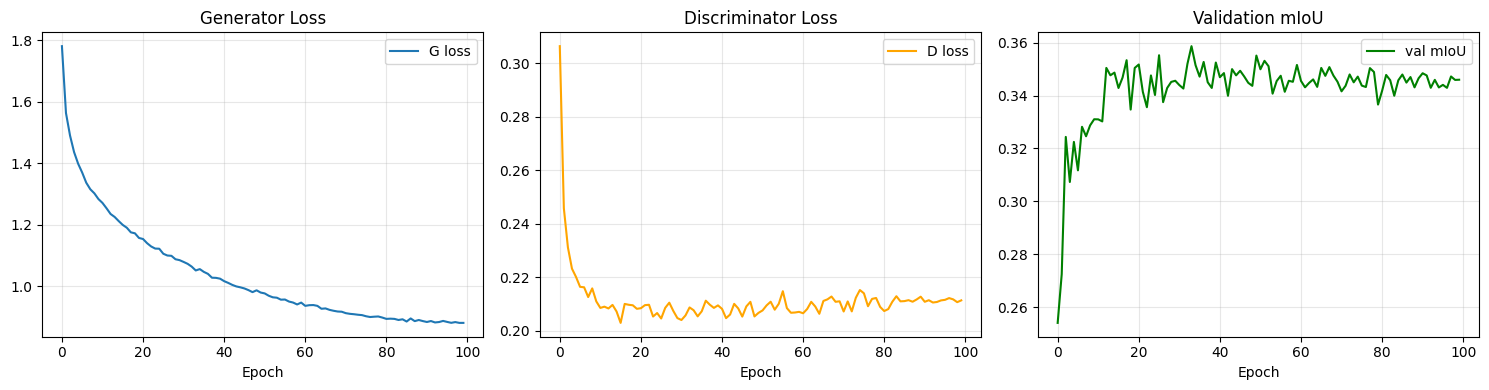

In [13]:
def plot_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history["g_loss"], label="G loss"); axes[0].set_title("Generator Loss")
    axes[1].plot(history["d_loss"], label="D loss", color="orange"); axes[1].set_title("Discriminator Loss")
    axes[2].plot(history["val_miou"], label="val mIoU", color="green"); axes[2].set_title("Validation mIoU")
    for ax in axes:
        ax.legend(); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()

plot_history(history)


In [15]:
def predict_and_visualize(model_path, image_path, save_path=None, mask_path=None):
    """
    Load checkpoint và dự đoán mask cho ảnh vệ tinh bất kỳ.

    Args:
        model_path : đường dẫn file .pth checkpoint Generator.
        image_path : đường dẫn ảnh vệ tinh RGB đầu vào.
        save_path  : (tuỳ chọn) lưu figure kết quả ra file.
        mask_path  : (tuỳ chọn) đường dẫn ground-truth mask (grayscale
                     LoveDA format: nhãn 1-7) để tính và hiển thị IoU.

    Luồng xử lý:
        1. Pad ảnh và chia thành các patch IMG_SIZE×IMG_SIZE (sliding window,
           stride = IMG_SIZE, không overlap) để xử lý ảnh kích thước bất kỳ.
        2. Mỗi patch normalize theo ImageNet rồi forward qua Generator.
        3. Ghép kết quả argmax thành pred_map toàn ảnh, cắt về kích thước gốc.
        4. Hiển thị: ảnh gốc | mask tô màu | overlay (alpha=0.5)
           + biểu đồ phân bố lớp (%).
        5. Nếu có mask_path: thêm cột ground-truth và in per-class IoU / mIoU.
    """
    # ── 1. Load model ──────────────────────────────────────────────
    model = smp.DeepLabV3Plus(
        encoder_name="resnet50", encoder_weights=None,
        in_channels=3, classes=NUM_CLASSES, activation=None,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # ── 2. Đọc ảnh gốc ─────────────────────────────────────────────
    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = orig.shape[:2]

    # ── 3. Sliding-window inference ────────────────────────────────
    _norm = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    pad_h  = (IMG_SIZE - H % IMG_SIZE) % IMG_SIZE
    pad_w  = (IMG_SIZE - W % IMG_SIZE) % IMG_SIZE
    padded = np.pad(orig, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    pH, pW = padded.shape[:2]

    pred_map = np.zeros((pH, pW), dtype=np.uint8)
    with torch.no_grad():
        for y in range(0, pH, IMG_SIZE):
            for x in range(0, pW, IMG_SIZE):
                patch = padded[y:y + IMG_SIZE, x:x + IMG_SIZE]
                inp   = _norm(image=patch)["image"].unsqueeze(0).to(device)
                out   = model(inp).argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)
                pred_map[y:y + IMG_SIZE, x:x + IMG_SIZE] = out

    pred_map = pred_map[:H, :W]   # cắt về kích thước gốc

    # ── 4. Tô màu và tạo overlay ───────────────────────────────────
    colored = COLOR_MAP[pred_map]                                    # [H, W, 3] uint8
    overlay = (orig * 0.5 + colored * 0.5).astype(np.uint8)

    # ── 5. (Tuỳ chọn) Ground-truth & per-class IoU ─────────────────
    gt_mask   = None
    class_iou = None
    miou      = None
    if mask_path is not None and os.path.exists(mask_path):
        gt_raw  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE).astype(np.int32)
        gt_raw[gt_raw == 255] = 1
        gt_mask = np.clip(gt_raw - 1, 0, NUM_CLASSES - 1).astype(np.uint8)

        class_iou = []
        for c in range(NUM_CLASSES):
            inter = ((pred_map == c) & (gt_mask == c)).sum()
            union = ((pred_map == c) | (gt_mask == c)).sum()
            class_iou.append(inter / union if union > 0 else float("nan"))
        miou = np.nanmean(class_iou)

        print(f"mIoU = {miou:.4f}")
        for i, (name, iou) in enumerate(zip(CLASS_NAMES, class_iou)):
            tag = f"{iou:.4f}" if not np.isnan(iou) else "  N/A"
            print(f"  [{i}] {name:<15s}: IoU = {tag}")

    # ── 6. Thống kê tỉ lệ class ────────────────────────────────────
    total_px     = pred_map.size
    class_ratios = [(pred_map == c).sum() / total_px * 100 for c in range(NUM_CLASSES)]

    # ── 7. Vẽ figure ───────────────────────────────────────────────
    has_gt  = gt_mask is not None
    n_img   = 4 if has_gt else 3               # số cột ảnh
    fig_w   = 5 * n_img + 4                    # tổng chiều rộng

    fig = plt.figure(figsize=(fig_w, 6))
    gs  = fig.add_gridspec(
        1, n_img + 1,
        width_ratios=[4] * n_img + [3],
        wspace=0.35,
    )

    # Ảnh gốc
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(orig)
    ax0.set_title("Ảnh vệ tinh gốc", fontsize=12, fontweight="bold")
    ax0.axis("off")

    # Mask dự đoán tô màu
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(colored)
    ax1.set_title("Phân đoạn (GAN)", fontsize=12, fontweight="bold")
    ax1.axis("off")

    # Overlay
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(overlay)
    ax2.set_title("Overlay (α=0.5)", fontsize=12, fontweight="bold")
    ax2.axis("off")

    # Ground-truth (tuỳ chọn)
    if has_gt:
        ax3 = fig.add_subplot(gs[0, 3])
        ax3.imshow(COLOR_MAP[gt_mask])
        gt_title = f"Ground Truth\n(mIoU = {miou:.3f})" if miou is not None else "Ground Truth"
        ax3.set_title(gt_title, fontsize=12, fontweight="bold")
        ax3.axis("off")

    # Biểu đồ phân bố class
    ax_bar = fig.add_subplot(gs[0, n_img])
    bar_colors = [COLOR_MAP[i] / 255.0 for i in range(NUM_CLASSES)]
    bars = ax_bar.barh(
        range(NUM_CLASSES), class_ratios,
        color=bar_colors, edgecolor="grey", linewidth=0.5,
    )
    ax_bar.set_yticks(range(NUM_CLASSES))
    ax_bar.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax_bar.set_xlabel("Tỉ lệ (%)", fontsize=9)
    ax_bar.set_title("Phân bố lớp", fontsize=11, fontweight="bold")
    ax_bar.invert_yaxis()
    ax_bar.grid(axis="x", alpha=0.3)
    for bar, ratio in zip(bars, class_ratios):
        if ratio > 1.5:
            ax_bar.text(
                bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{ratio:.1f}%", va="center", fontsize=8,
            )

    # Legend chung
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color=COLOR_MAP[i] / 255.0, label=CLASS_NAMES[i])
        for i in range(NUM_CLASSES)
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center", ncol=NUM_CLASSES,
        fontsize=9, framealpha=0.9, edgecolor="#ccc",
        bbox_to_anchor=(0.45, -0.04),
    )
    plt.suptitle(
        f"Kết quả phân đoạn: {os.path.basename(image_path)}",
        fontsize=13, fontweight="bold", y=1.02,
    )

    if save_path:
        os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Đã lưu kết quả → {save_path}")
    plt.show()
    return pred_map

mIoU = 0.4785
  [0] Background     : IoU = 0.5267
  [1] Building       : IoU =   N/A
  [2] Road           : IoU = 0.0000
  [3] Water          : IoU = 0.9596
  [4] Barren         : IoU = 0.0000
  [5] Forest         : IoU = 0.6791
  [6] Agricultural   : IoU = 0.7052


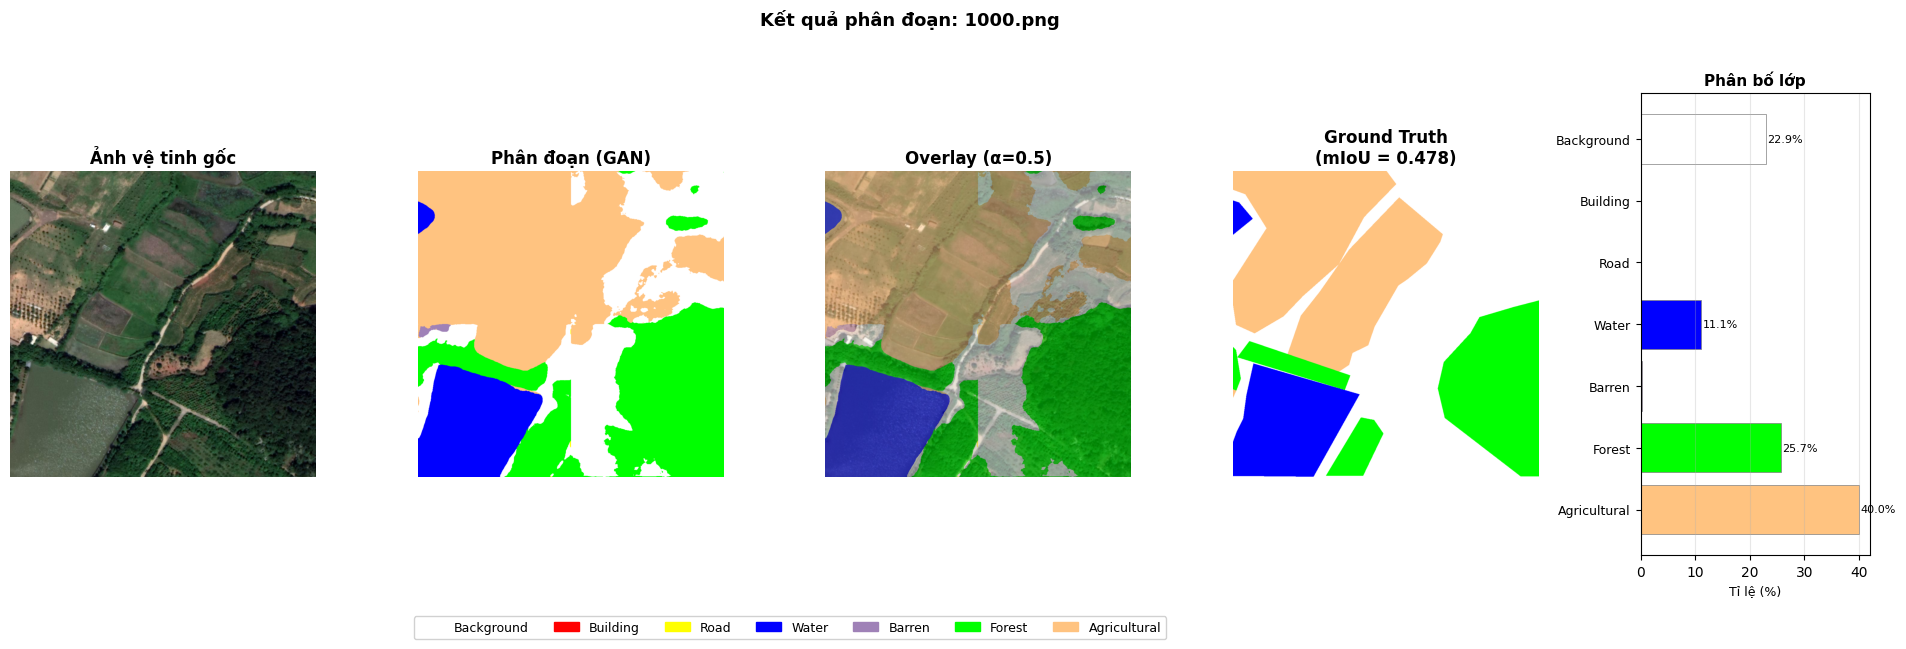

array([[6, 6, 6, ..., 0, 0, 0],
       [6, 6, 6, ..., 0, 0, 0],
       [6, 6, 6, ..., 0, 0, 0],
       ...,
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5]], shape=(1024, 1024), dtype=uint8)

In [28]:
predict_and_visualize(
    model_path = "best_generator.pth",
    image_path = "./Train/Train/Rural/images_png/1000.png",  # ảnh train cụ thể
    mask_path  = "./Train/Train/Rural/masks_png/1000.png",   # mask thật của ảnh đó
)


mIoU = 0.6994
  [0] Background     : IoU = 0.8183
  [1] Building       : IoU =   N/A
  [2] Road           : IoU =   N/A
  [3] Water          : IoU = 0.9700
  [4] Barren         : IoU = 0.0000
  [5] Forest         : IoU = 0.8571
  [6] Agricultural   : IoU = 0.8515


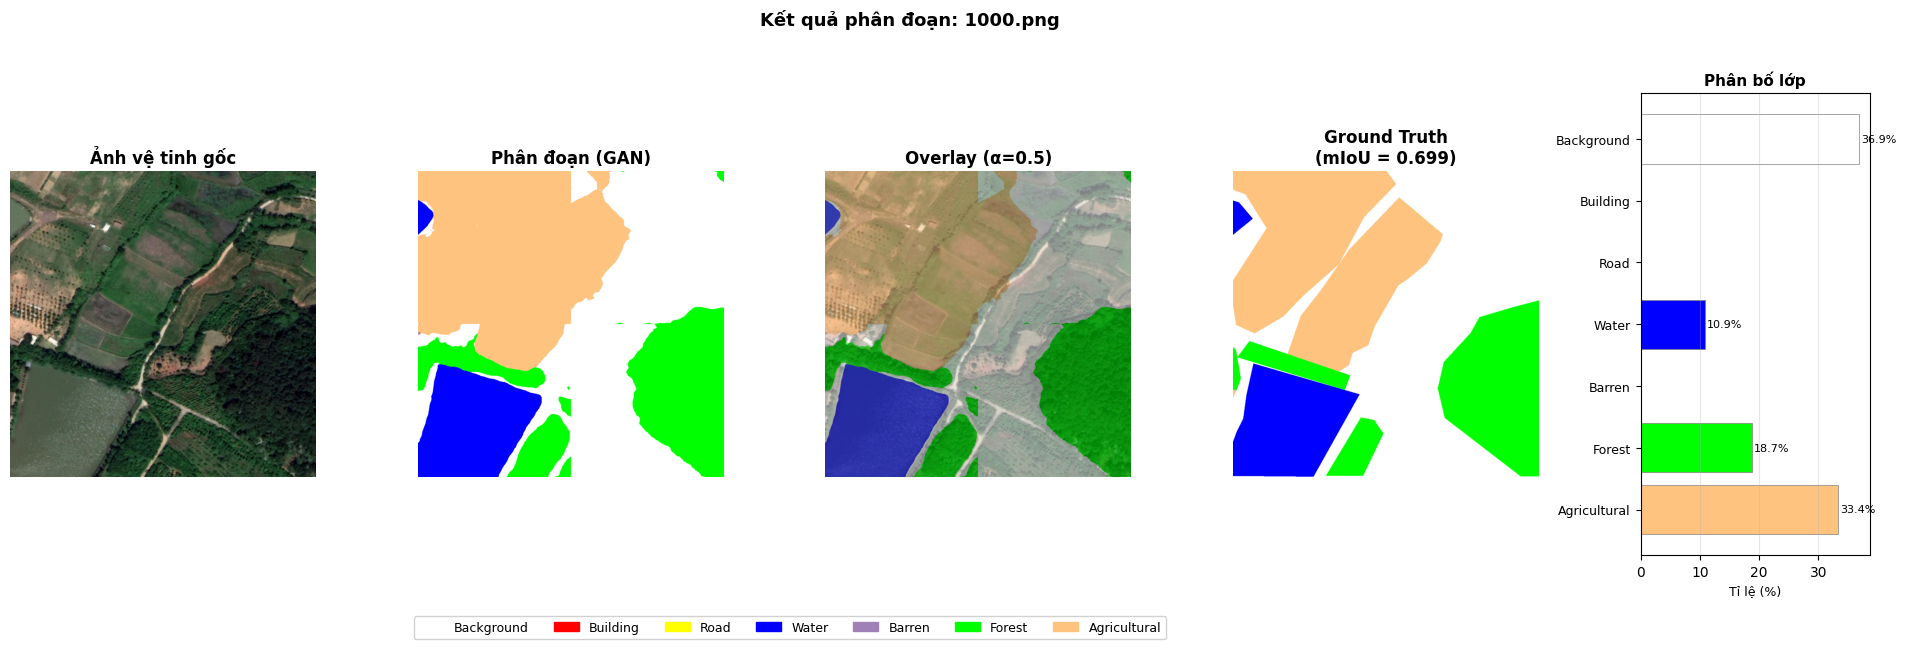

array([[6, 6, 6, ..., 5, 5, 5],
       [6, 6, 6, ..., 5, 5, 5],
       [6, 6, 6, ..., 5, 5, 5],
       ...,
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5]], shape=(1024, 1024), dtype=uint8)

In [29]:
predict_and_visualize(
    model_path = "last_generator.pth",
    image_path = "./Train/Train/Rural/images_png/1000.png",  # ảnh train cụ thể
    mask_path  = "./Train/Train/Rural/masks_png/1000.png",   # mask thật của ảnh đó
)


In [5]:
def predict_and_visualize(model_path, image_path, save_path=None, mask_path=None):
    """
    Load checkpoint và dự đoán mask cho ảnh vệ tinh bất kỳ.

    Args:
        model_path : đường dẫn file .pth checkpoint Generator.
        image_path : đường dẫn ảnh vệ tinh RGB đầu vào.
        save_path  : (tuỳ chọn) lưu figure kết quả ra file.
        mask_path  : (tuỳ chọn) đường dẫn ground-truth mask (grayscale
                     LoveDA format: nhãn 1-7) để tính và hiển thị IoU.

    Luồng xử lý:
        1. Pad ảnh và chia thành các patch IMG_SIZE×IMG_SIZE (sliding window,
           stride = IMG_SIZE//2, overlap 50%) để xử lý ảnh kích thước bất kỳ.
        2. Mỗi patch normalize theo ImageNet rồi forward qua Generator.
        3. Cộng dồn logits (float32) lên logit_sum và đếm số lần mỗi pixel
           được dự đoán (count_map), sau đó lấy argmax của trung bình logits.
           → Khử artifact đường biên giữa các patch.
        4. Hiển thị: ảnh gốc | mask tô màu | overlay (alpha=0.5)
           + biểu đồ phân bố lớp (%).
        5. Nếu có mask_path: thêm cột ground-truth và in per-class IoU / mIoU.
    """
    # ── 1. Load model ──────────────────────────────────────────────
    model = smp.DeepLabV3Plus(
        encoder_name="resnet50", encoder_weights=None,
        in_channels=3, classes=NUM_CLASSES, activation=None,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # ── 2. Đọc ảnh gốc ─────────────────────────────────────────────
    orig = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = orig.shape[:2]

    # ── 3. Sliding-window inference ────────────────────────────────
    _norm = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    STRIDE = IMG_SIZE // 2   # 50% overlap → khử artifact biên patch

    # Pad đủ để patch cuối cùng không bị cắt ngắn
    pad_h  = (IMG_SIZE - H % IMG_SIZE) % IMG_SIZE
    pad_w  = (IMG_SIZE - W % IMG_SIZE) % IMG_SIZE
    # Thêm một stride nữa để sliding window luôn phủ hết mọi pixel
    pad_h += STRIDE
    pad_w += STRIDE
    padded = np.pad(orig, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
    pH, pW = padded.shape[:2]

    logit_sum = np.zeros((pH, pW, NUM_CLASSES), dtype=np.float32)  # tổng logits
    count_map = np.zeros((pH, pW),              dtype=np.float32)  # số lần mỗi pixel được predict

    with torch.no_grad():
        for y in range(0, pH - IMG_SIZE + 1, STRIDE):
            for x in range(0, pW - IMG_SIZE + 1, STRIDE):
                patch = padded[y:y + IMG_SIZE, x:x + IMG_SIZE]
                inp   = _norm(image=patch)["image"].unsqueeze(0).to(device)
                # logits: [1, C, H, W] → [H, W, C] trên CPU
                logit = model(inp).squeeze(0).permute(1, 2, 0).cpu().numpy()
                logit_sum[y:y + IMG_SIZE, x:x + IMG_SIZE] += logit
                count_map[y:y + IMG_SIZE, x:x + IMG_SIZE] += 1

    # Chia trung bình logits rồi lấy argmax
    count_map = np.maximum(count_map, 1)                           # tránh chia 0
    avg_logit = logit_sum / count_map[..., np.newaxis]             # [pH, pW, C]
    pred_map  = avg_logit.argmax(axis=-1).astype(np.uint8)[:H, :W]  # cắt về kích thước gốc

    # ── 4. Tô màu và tạo overlay ───────────────────────────────────
    colored = COLOR_MAP[pred_map]                                    # [H, W, 3] uint8
    overlay = (orig * 0.5 + colored * 0.5).astype(np.uint8)

    # ── 5. (Tuỳ chọn) Ground-truth & per-class IoU ─────────────────
    gt_mask   = None
    class_iou = None
    miou      = None
    if mask_path is not None and os.path.exists(mask_path):
        gt_raw  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE).astype(np.int32)
        gt_raw[gt_raw == 255] = 1
        gt_mask = np.clip(gt_raw - 1, 0, NUM_CLASSES - 1).astype(np.uint8)

        class_iou = []
        for c in range(NUM_CLASSES):
            inter = ((pred_map == c) & (gt_mask == c)).sum()
            union = ((pred_map == c) | (gt_mask == c)).sum()
            class_iou.append(inter / union if union > 0 else float("nan"))
        miou = np.nanmean(class_iou)

        print(f"mIoU = {miou:.4f}")
        for i, (name, iou) in enumerate(zip(CLASS_NAMES, class_iou)):
            tag = f"{iou:.4f}" if not np.isnan(iou) else "  N/A"
            print(f"  [{i}] {name:<15s}: IoU = {tag}")

    # ── 6. Thống kê tỉ lệ class ────────────────────────────────────
    total_px     = pred_map.size
    class_ratios = [(pred_map == c).sum() / total_px * 100 for c in range(NUM_CLASSES)]

    # ── 7. Vẽ figure ───────────────────────────────────────────────
    has_gt  = gt_mask is not None
    n_img   = 4 if has_gt else 3               # số cột ảnh
    fig_w   = 5 * n_img + 4                    # tổng chiều rộng

    fig = plt.figure(figsize=(fig_w, 6))
    gs  = fig.add_gridspec(
        1, n_img + 1,
        width_ratios=[4] * n_img + [3],
        wspace=0.35,
    )

    # Ảnh gốc
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(orig)
    ax0.set_title("Ảnh vệ tinh gốc", fontsize=12, fontweight="bold")
    ax0.axis("off")

    # Mask dự đoán tô màu
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(colored)
    ax1.set_title("Phân đoạn (GAN)", fontsize=12, fontweight="bold")
    ax1.axis("off")

    # Overlay
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(overlay)
    ax2.set_title("Overlay (α=0.5)", fontsize=12, fontweight="bold")
    ax2.axis("off")

    # Ground-truth (tuỳ chọn)
    if has_gt:
        ax3 = fig.add_subplot(gs[0, 3])
        ax3.imshow(COLOR_MAP[gt_mask])
        gt_title = f"Ground Truth\n(mIoU = {miou:.3f})" if miou is not None else "Ground Truth"
        ax3.set_title(gt_title, fontsize=12, fontweight="bold")
        ax3.axis("off")

    # Biểu đồ phân bố class
    ax_bar = fig.add_subplot(gs[0, n_img])
    bar_colors = [COLOR_MAP[i] / 255.0 for i in range(NUM_CLASSES)]
    bars = ax_bar.barh(
        range(NUM_CLASSES), class_ratios,
        color=bar_colors, edgecolor="grey", linewidth=0.5,
    )
    ax_bar.set_yticks(range(NUM_CLASSES))
    ax_bar.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax_bar.set_xlabel("Tỉ lệ (%)", fontsize=9)
    ax_bar.set_title("Phân bố lớp", fontsize=11, fontweight="bold")
    ax_bar.invert_yaxis()
    ax_bar.grid(axis="x", alpha=0.3)
    for bar, ratio in zip(bars, class_ratios):
        if ratio > 1.5:
            ax_bar.text(
                bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{ratio:.1f}%", va="center", fontsize=8,
            )

    # Legend chung
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, color=COLOR_MAP[i] / 255.0, label=CLASS_NAMES[i])
        for i in range(NUM_CLASSES)
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center", ncol=NUM_CLASSES,
        fontsize=9, framealpha=0.9, edgecolor="#ccc",
        bbox_to_anchor=(0.45, -0.04),
    )
    plt.suptitle(
        f"Kết quả phân đoạn: {os.path.basename(image_path)}",
        fontsize=13, fontweight="bold", y=1.02,
    )

    if save_path:
        os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Đã lưu kết quả → {save_path}")
    plt.show()
    return pred_map


# Ví dụ chạy inference sau khi train xong:
# predict_and_visualize(
#     "best_generator.pth",
#     "./Test/Test/Urban/images_png/5167.png",
#     save_path="./predictions/5167_result.png",
#     mask_path=None,  # hoặc truyền đường dẫn mask GT để tính IoU
# )


mIoU = 0.8495
  [0] Background     : IoU = 0.7757
  [1] Building       : IoU =   N/A
  [2] Road           : IoU =   N/A
  [3] Water          : IoU = 0.9704
  [4] Barren         : IoU =   N/A
  [5] Forest         : IoU = 0.8330
  [6] Agricultural   : IoU = 0.8190


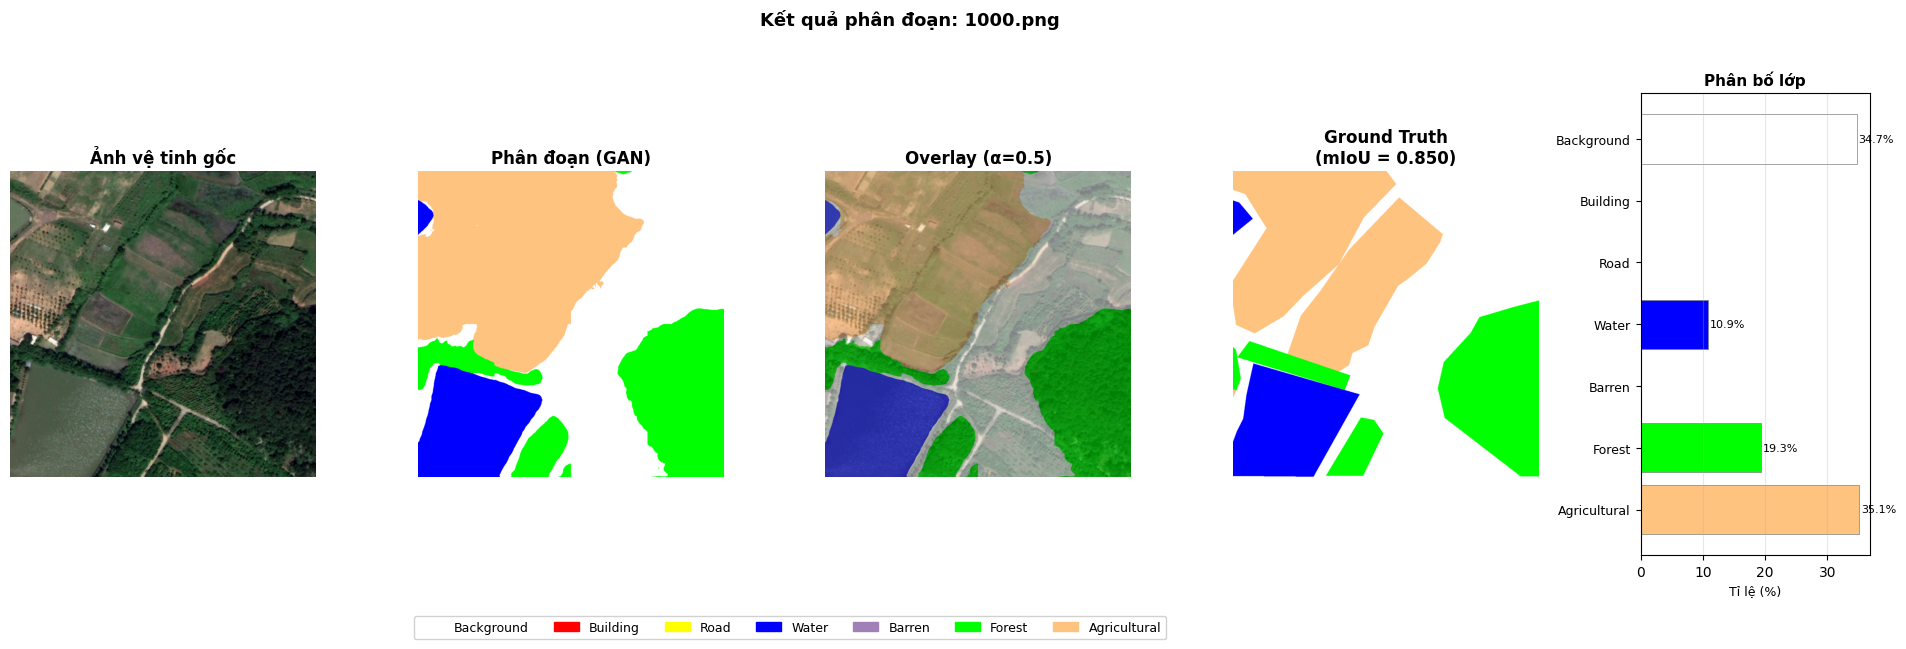

array([[6, 6, 6, ..., 0, 0, 0],
       [6, 6, 6, ..., 0, 0, 0],
       [6, 6, 6, ..., 0, 0, 0],
       ...,
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5],
       [3, 3, 3, ..., 5, 5, 5]], shape=(1024, 1024), dtype=uint8)

In [6]:
predict_and_visualize(
    model_path = "last_generator.pth",
    image_path = "./Train/Train/Rural/images_png/1000.png",  # ảnh train cụ thể
    mask_path  = "./Train/Train/Rural/masks_png/1000.png",   # mask thật của ảnh đó
)